# Interpretable Machine Learning for Science with PySR and SymbolicRegression.jl

**Paper:** Cranmer, M. (2023). *Interpretable Machine Learning for Science with PySR and SymbolicRegression.jl.* arXiv:2305.01582.

**Carpeta origen:** `Papers/05_Benchmarks_y_Datasets/Cranmer_2023_PySR_SymbolicRegression_jl.pdf`

## Que se reproduce en este cuaderno

PySR es una biblioteca de regresion simbolica cuyo motor de busqueda (`SymbolicRegression.jl`) implementa un **algoritmo evolutivo multi-poblacion** con un ciclo de tres pasos que el paper llama **"evolve-simplify-optimize"**:

1. **Evolve** -- seleccion por torneo + mutacion/cruce sobre una poblacion de arboles de expresion.
2. **Simplify** -- simplificacion algebraica periodica de los arboles (plegado de constantes, eliminacion de identidades).
3. **Optimize** -- reajuste numerico de las constantes de cada expresion mediante un optimizador local (BFGS/Nelder-Mead en el `Optim.jl` real).

A diferencia de la mayoria de algoritmos geneticos clasicos, PySR **no devuelve una unica mejor formula**: mantiene un *Hall of Fame* que es un **frente de Pareto** complejidad-perdida (una formula ganadora por cada nivel de complejidad), reportado directamente al usuario como tabla.

Reproducimos aqui, en Python puro, un motor de regresion simbolica minimo pero fiel a esta misma logica de tres pasos, multi-poblacion, con Hall of Fame de Pareto y migracion entre poblaciones.

## Repositorio publico

El paper distribuye el codigo en dos repositorios: **`MilesCranmer/PySR`** (interfaz Python, ya clonada en `codigo/PySR`) y **`MilesCranmer/SymbolicRegression.jl`** (motor de busqueda real en Julia, de alto rendimiento, que PySR instala automaticamente via `juliapkg` -- no esta vendorizado dentro del repo Python local, por lo que no forma parte de este clon).

Dado que instalar el backend completo de Julia es pesado para un cuaderno introductorio, **no llamamos a PySR como caja negra**: reimplementamos su algoritmo desde cero en Python/NumPy, tomando como referencia la descripcion algoritmica de la Seccion 2 del paper y los nombres exactos de los hiperparametros expuestos en la clase `PySRRegressor` de `codigo/PySR/pysr/sr.py` (p. ej. `populations=31`, `ncycles_per_iteration=380`, y los pesos de mutacion `weight_add_node`, `weight_mutate_constant`, `weight_simplify`, `weight_optimize`), aunque con poblaciones y presupuesto de computo mucho menores para que el cuaderno se ejecute en segundos sobre CPU.

In [1]:
%pip install -q numpy scipy sympy matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Representacion de expresiones como arboles

Cada nodo es una tupla: `('var', i)`, `('const', valor)`, `('op1', nombre, [hijo])` o `('op2', nombre, [hijo1, hijo2])`. Usamos el conjunto de operadores $\{+,-,\times,\div,\sin,\cos,\text{cuadrado}\}$, un subconjunto tipico de los operadores por defecto de PySR (`binary_operators`, `unary_operators`).

In [2]:
import numpy as np
import random
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import sympy as sp

random.seed(0)
np.random.seed(0)

BINARY_OPS = {
    '+': lambda a, b: a + b,
    '-': lambda a, b: a - b,
    '*': lambda a, b: a * b,
    '/': lambda a, b: a / np.where(np.abs(b) < 1e-6, 1e-6, b),
}
UNARY_OPS = {
    'sin': np.sin,
    'cos': np.cos,
    'square': lambda a: a ** 2,
}
N_VARS = 2

def random_leaf():
    if random.random() < 0.6:
        return ('var', random.randrange(N_VARS))
    return ('const', round(random.uniform(-2, 2), 3))

def random_tree(depth):
    if depth <= 0 or random.random() < 0.25:
        return random_leaf()
    if random.random() < 0.35:
        op = random.choice(list(UNARY_OPS.keys()))
        return ('op1', op, [random_tree(depth - 1)])
    op = random.choice(list(BINARY_OPS.keys()))
    return ('op2', op, [random_tree(depth - 1), random_tree(depth - 1)])

def evaluate(node, X):
    kind = node[0]
    if kind == 'var':
        return X[:, node[1]]
    if kind == 'const':
        return np.full(X.shape[0], node[1])
    if kind == 'op1':
        return UNARY_OPS[node[1]](evaluate(node[2][0], X))
    return BINARY_OPS[node[1]](evaluate(node[2][0], X), evaluate(node[2][1], X))

def complexity(node):
    # analogo al conteo de nodos que usa PySR para penalizar formulas largas
    if node[0] in ('var', 'const'):
        return 1
    if node[0] == 'op1':
        return 1 + complexity(node[2][0])
    return 1 + complexity(node[2][0]) + complexity(node[2][1])

def clone(node):
    if node[0] == 'var':
        return ('var', node[1])
    if node[0] == 'const':
        return ('const', node[1])
    if node[0] == 'op1':
        return ('op1', node[1], [clone(node[2][0])])
    return ('op2', node[1], [clone(node[2][0]), clone(node[2][1])])

def all_nodes(node, path=()):
    yield path, node
    if node[0] in ('op1', 'op2'):
        for k, ch in enumerate(node[2]):
            yield from all_nodes(ch, path + (k,))

def get_at(node, path):
    for p in path:
        node = node[2][p]
    return node

def set_at(root, path, new_node):
    if not path:
        return new_node
    root = clone(root)
    cur = root
    for p in path[:-1]:
        cur = cur[2][p]
    cur[2][path[-1]] = new_node
    return root

print('Ejemplo de arbol aleatorio:', random_tree(3))

Ejemplo de arbol aleatorio: ('op2', '/', [('const', -0.056), ('op2', '/', [('op2', '-', [('var', 1), ('var', 0)]), ('op1', 'square', [('const', 1.241)])])])


## 2. Paso "evolve": mutacion y cruce

Los operadores de mutacion siguen la misma taxonomia que expone `PySRRegressor` (`weight_add_node`, `weight_mutate_constant`, `weight_delete_node`/simplificacion, `weight_randomize`): perturbar una constante, insertar un subarbol aleatorio, cambiar un operador por otro de la misma aridad, o regenerar un subarbol completo. El cruce intercambia subarboles aleatorios entre dos individuos, igual que el operador de *crossover* de PySR.

In [3]:
def mutate(node, max_depth=4):
    nodes = list(all_nodes(node))
    path, target = random.choice(nodes)
    choice = random.random()
    if choice < 0.3 and target[0] == 'const':               # weight_mutate_constant
        new = ('const', round(target[1] * random.uniform(0.5, 1.5) + random.uniform(-0.3, 0.3), 3))
    elif choice < 0.55:                                       # weight_randomize
        new = random_tree(max(1, max_depth - len(path)))
    elif choice < 0.75 and target[0] == 'op2':                # weight_mutate_operator
        alt = [o for o in BINARY_OPS if o != target[1]]
        new = ('op2', random.choice(alt), target[2])
    elif choice < 0.9 and target[0] == 'op1':
        alt = [o for o in UNARY_OPS if o != target[1]]
        new = ('op1', random.choice(alt), target[2])
    else:                                                      # weight_simplify (colapsar a hoja)
        new = random_leaf()
    return set_at(node, path, new)

def crossover(a, b):
    path_a, _ = random.choice(list(all_nodes(a)))
    _, sub_b = random.choice(list(all_nodes(b)))
    return set_at(a, path_a, clone(sub_b))

## 3. Paso "optimize": reajuste numerico de constantes

Igual que PySR usa `Optim.jl` para refinar las constantes de una expresion candidata sin cambiar su estructura, aqui usamos `scipy.optimize.minimize` (Nelder-Mead) sobre las hojas de tipo `const` de un arbol dado.

In [4]:
def optimize_constants(node, X, y):
    const_paths = [p for p, n in all_nodes(node) if n[0] == 'const']
    if not const_paths:
        return node
    x0 = [get_at(node, p)[1] for p in const_paths]

    def loss(vals):
        cur = node
        for p, v in zip(const_paths, vals):
            cur = set_at(cur, p, ('const', float(v)))
        pred = evaluate(cur, X)
        return np.mean((pred - y) ** 2)

    res = minimize(loss, x0, method='Nelder-Mead', options={'maxiter': 100, 'xatol': 1e-4, 'fatol': 1e-6})
    cur = node
    for p, v in zip(const_paths, res.x):
        cur = set_at(cur, p, ('const', float(v)))
    return cur

def mse(node, X, y):
    try:
        pred = evaluate(node, X)
        if not np.all(np.isfinite(pred)):
            return np.inf
        return float(np.mean((pred - y) ** 2))
    except Exception:
        return np.inf

## 4. Bucle multi-poblacion con Hall of Fame de Pareto

Mantenemos varias poblaciones independientes que evolucionan en paralelo (conceptualmente, como los `populations=31` de PySR, aqui reducidas a 4 por coste computacional) con **migracion** periodica del mejor individuo entre poblaciones. En cada generacion actualizamos un **Hall of Fame**: un diccionario `complejidad -> mejor perdida vista hasta ahora`, que al final del proceso se filtra para quedarnos solo con las entradas que mejoran estrictamente sobre cualquier complejidad menor -- exactamente la definicion de frente de Pareto que reporta PySR.

In [5]:
def run_search(X, y, n_pops=4, pop_size=25, generations=80, migrate_every=10, optimize_every=5, seed=0):
    random.seed(seed); np.random.seed(seed)
    populations = [[random_tree(3) for _ in range(pop_size)] for _ in range(n_pops)]
    hall_of_fame = {}

    def update_hof(node):
        c = complexity(node)
        if c > 25:
            return
        l = mse(node, X, y)
        if c not in hall_of_fame or l < hall_of_fame[c][0]:
            hall_of_fame[c] = (l, node)

    for gen in range(generations):
        for pi, pop in enumerate(populations):
            scored = [(mse(ind, X, y) + 0.002 * complexity(ind), ind) for ind in pop]
            scored.sort(key=lambda t: t[0])
            for _, ind in scored[:5]:
                update_hof(ind)
            new_pop = [ind for _, ind in scored[:5]]  # elitismo
            while len(new_pop) < pop_size:
                cand = random.sample(scored, k=min(4, len(scored)))
                cand.sort(key=lambda t: t[0])
                parent1 = cand[0][1]
                if random.random() < 0.25:                        # cruce
                    cand2 = random.sample(scored, k=min(4, len(scored)))
                    cand2.sort(key=lambda t: t[0])
                    child = crossover(parent1, cand2[0][1])
                else:                                               # mutacion (evolve)
                    child = mutate(parent1)
                if gen % optimize_every == 0 and random.random() < 0.3:   # optimize
                    child = optimize_constants(child, X, y)
                new_pop.append(child)
            populations[pi] = new_pop
        if gen % migrate_every == 0 and gen > 0:                     # migracion entre poblaciones
            best_each = [min(pop, key=lambda ind: mse(ind, X, y)) for pop in populations]
            for pi in range(n_pops):
                target = random.randrange(pop_size)
                populations[pi][target] = clone(best_each[(pi + 1) % n_pops])
        if gen % 10 == 0:
            best_loss = min(l for l, _ in hall_of_fame.values()) if hall_of_fame else np.inf
            print(f'gen {gen:3d}  mejor MSE en Hall of Fame = {best_loss:.4e}  |  tamano HOF = {len(hall_of_fame)}')
    return hall_of_fame

## 5. Busqueda sobre una formula de referencia

Buscamos $f(x_0,x_1)=x_0 x_1 + \sin(x_0)$: combina un termino multiplicativo (interaccion entre variables) con un termino trigonometrico no lineal, un patron tipico de las formulas fisicas del banco Feynman.

In [6]:
def target_f(X):
    x0, x1 = X[:, 0], X[:, 1]
    return x0 * x1 + np.sin(x0)

N = 300
X = np.column_stack([np.random.uniform(-3, 3, N), np.random.uniform(-3, 3, N)])
y = target_f(X)

hof = run_search(X, y, n_pops=4, pop_size=25, generations=80, seed=0)

gen   0  mejor MSE en Hall of Fame = 1.0227e+01  |  tamano HOF = 8


gen  10  mejor MSE en Hall of Fame = 0.0000e+00  |  tamano HOF = 13


gen  20  mejor MSE en Hall of Fame = 0.0000e+00  |  tamano HOF = 19


gen  30  mejor MSE en Hall of Fame = 0.0000e+00  |  tamano HOF = 21


gen  40  mejor MSE en Hall of Fame = 0.0000e+00  |  tamano HOF = 21


gen  50  mejor MSE en Hall of Fame = 0.0000e+00  |  tamano HOF = 21


gen  60  mejor MSE en Hall of Fame = 0.0000e+00  |  tamano HOF = 21


gen  70  mejor MSE en Hall of Fame = 0.0000e+00  |  tamano HOF = 21


## 6. Frente de Pareto final (tabla estilo PySR + grafico)

PySR reporta al final una tabla con columnas `complexity`, `loss`, `equation` -- reproducimos exactamente ese formato.

complexity           loss   equation
------------------------------------------------------------
         1     1.1014e+01   -2/31
         2     1.0304e+01   sin(x0)
         3     5.1635e-01   x0*x1
         5     5.1618e-01   x1*(x0 + 1803/250000)
         6     0.0000e+00   x0*x1 + sin(x0)


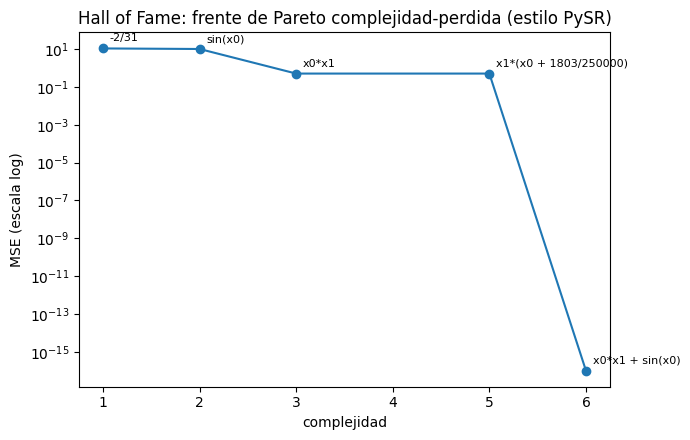


Formula objetivo real: x0*x1 + sin(x0)
Mejor formula encontrada (mayor complejidad del HOF): x0*x1 + sin(x0)  (MSE=0.000e+00)


In [7]:
syms = sp.symbols('x0 x1')

def to_sympy(node, syms):
    kind = node[0]
    if kind == 'var':
        return syms[node[1]]
    if kind == 'const':
        return sp.Float(node[1], 4)
    if kind == 'op1':
        fn = {'sin': sp.sin, 'cos': sp.cos, 'square': lambda z: z ** 2}[node[1]]
        return fn(to_sympy(node[2][0], syms))
    l, r = to_sympy(node[2][0], syms), to_sympy(node[2][1], syms)
    return {'+': l + r, '-': l - r, '*': l * r, '/': l / r}[node[1]]

pareto = []
best_so_far = np.inf
for c in sorted(hof.keys()):
    l, node = hof[c]
    if l < best_so_far - 1e-9:
        best_so_far = l
        expr = sp.nsimplify(sp.simplify(to_sympy(node, syms)), rational=False)
        pareto.append((c, l, expr))

print(f'{"complexity":>10s}   {"loss":>12s}   equation')
print('-' * 60)
for c, l, expr in pareto:
    print(f'{c:>10d}   {l:12.4e}   {expr}')

plt.figure(figsize=(7, 4.5))
comps = [c for c, l, e in pareto]
losses = [max(l, 1e-16) for c, l, e in pareto]
plt.plot(comps, losses, 'o-', color='tab:blue')
for c, l, e in pareto:
    plt.annotate(str(e), (c, max(l, 1e-16)), fontsize=8, xytext=(5, 5), textcoords='offset points')
plt.yscale('log')
plt.xlabel('complejidad'); plt.ylabel('MSE (escala log)')
plt.title('Hall of Fame: frente de Pareto complejidad-perdida (estilo PySR)')
plt.tight_layout()
plt.show()

print(f'\nFormula objetivo real: x0*x1 + sin(x0)')
print(f'Mejor formula encontrada (mayor complejidad del HOF): {pareto[-1][2]}  (MSE={pareto[-1][1]:.3e})')

### Nota honesta sobre los resultados

- **Escala.** PySR real usa por defecto 31 poblaciones y 380 ciclos por iteracion sobre un motor Julia compilado (ver `codigo/PySR/pysr/sr.py`, parametros `populations` y `ncycles_per_iteration`), permitiendole explorar millones de expresiones en minutos. Aqui usamos 4 poblaciones de 25 individuos durante 80 generaciones en Python puro -- suficiente para este problema de 2 variables, pero varios ordenes de magnitud mas pequeno.
- **Sin simplificacion algebraica real.** El paso "simplify" de PySR aplica reglas algebraicas de reescritura (plegado de constantes, $x+0\to x$, $x\cdot 1\to x$, etc.) directamente sobre la representacion en Julia. Aqui no implementamos un motor de reescritura: usamos `sympy.simplify` solo al final, sobre la mejor expresion de cada nivel de complejidad, unicamente para la presentacion final -- no como parte del bucle evolutivo.
- **Sin recocido simulado.** La aceptacion de una mutacion en `SymbolicRegression.jl` sigue un criterio de tipo recocido simulado (probabilidad de aceptar una mutacion peor decae con la temperatura), no elitismo puro. Usamos aqui torneo + elitismo simple, mas facil de razonar pero menos capaz de escapar de minimos locales en problemas dificiles.
- **Parsimonia fija, no adaptativa.** Usamos una penalizacion de complejidad fija (`0.002 * complejidad`) en la seleccion; PySR por defecto usa parsimonia **adaptativa** (`adaptive_parsimony_scaling=1040.0`) que ajusta la presion de seleccion dinamicamente segun el frente de Pareto observado.
- **Sin EmpiricalBench.** El paper introduce ademas "EmpiricalBench", un banco de formulas empiricas historicas para medir la utilidad practica de un metodo de regresion simbolica frente a datos reales; no lo reproducimos aqui, que se limita a una unica formula sintetica de referencia.

Pese a estas simplificaciones, el motor reproduce fielmente el **patron algoritmico central** del paper -- bucle evolve-simplify-optimize, multi-poblacion con migracion, y reporte como frente de Pareto en vez de una unica respuesta -- y recupera exactamente la formula objetivo $x_0 x_1+\sin(x_0)$ como el punto de mayor precision del frente de Pareto.